# Data Exploration and Quality Assessment

This notebook performs comprehensive exploratory data analysis (EDA) on disaster data, including:
- Data quality assessment
- Descriptive statistics
- Temporal coverage analysis
- Missing value analysis
- Initial visualizations

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from config import RAW_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, HAZARD_TYPES
from src.data_processing import load_and_validate_disaster_data, clean_disaster_data, add_derived_columns
from src.utils import get_data_quality_summary, load_disaster_data
from src.visualization import plot_temporal_trends, plot_hazard_frequency

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")
print(f"Project root: {project_root}")

Libraries imported successfully!
Project root: D:\Projects\sendai-multi-hazard-risk-modeling


## 1. Load Raw Data

In [2]:
raw_data_file = RAW_DATA_DIR / 'disaster_events.csv'

if raw_data_file.exists():
    df_raw = pd.read_csv(raw_data_file, low_memory=False)
    print(f"Loaded {len(df_raw)} records from {raw_data_file}")
else:
    print(f"Data file not found: {raw_data_file}")
    print("Please place your disaster data CSV file in the data/raw/ directory")
    print("Expected columns: serial, year, month, day, eventname, hazardtype, deaths, injured, etc.")
    df_raw = None

Loaded 30 records from D:\Projects\sendai-multi-hazard-risk-modeling\data\raw\disaster_events.csv


## 2. Initial Data Overview

In [3]:
if df_raw is not None:
    print("Dataset Shape:", df_raw.shape)
    print("\nColumn Names:")
    print(df_raw.columns.tolist())
    print("\nFirst few rows:")
    display(df_raw.head())
    print("\nData types:")
    display(df_raw.dtypes)

Dataset Shape: (30, 25)

Column Names:
['serial', 'glide', 'year', 'month', 'day', 'eventname', 'level1', 'level2', 'level3', 'latitude', 'longitude', 'hazardtype', 'deaths', 'injured', 'missing', 'affected', 'displaced', 'housesdestroyed', 'housesdamaged', 'educationcenters', 'healthcenters', 'localvalue', 'usdvalue', 'durationdays', 'eventdescription']

First few rows:


,serial,glide,year,month,day,eventname,level1,level2,level3,latitude,...,affected,displaced,housesdestroyed,housesdamaged,educationcenters,healthcenters,localvalue,usdvalue,durationdays,eventdescription
0,1,FL-2023-000123,2023,4,15,Seasonal Flooding,Kenya,Nairobi,Nairobi County,-1.2921,...,125000,35000,2500,8900,12,3,500000000,6000000,7,Severe seasonal flooding affected multiple dis...
1,2,DR-2023-000045,2023,2,6,Horn of Africa Drought,Ethiopia,Somali,Gode,5.9572,...,250000,85000,12500,45000,89,23,2500000000,30000000,180,Prolonged drought in pastoral areas
2,3,ST-2022-000234,2022,11,12,Tropical Cyclone,Tanzania,Dar es Salaam,Kinondoni,-6.7924,...,85000,12000,1200,5600,8,2,150000000,1800000,3,Tropical cyclone made landfall on coast
3,4,FL-2022-000156,2022,5,20,Flash Flood,Kenya,Rift Valley,Nakuru,-0.3031,...,450000,125000,8900,34000,45,12,800000000,9600000,5,Urban flash flooding from heavy rains
4,5,DR-2022-000089,2022,3,1,Drought,Somalia,Banadir,Mogadishu,2.0469,...,1200000,0,0,0,0,0,350000000,4200000,150,Prolonged drought affecting agriculture and li...



Data types:


serial                int64
glide                   str
year                  int64
month                 int64
day                   int64
eventname               str
level1                  str
level2                  str
level3                  str
latitude            float64
longitude           float64
hazardtype              str
deaths                int64
injured               int64
missing               int64
affected              int64
displaced             int64
housesdestroyed       int64
housesdamaged         int64
educationcenters      int64
healthcenters         int64
localvalue            int64
usdvalue              int64
durationdays          int64
eventdescription        str
dtype: object

## 3. Data Quality Assessment

In [4]:
if df_raw is not None:
    quality_summary = get_data_quality_summary(df_raw)
    print("Data Quality Summary:")
    display(quality_summary)
    
    print("\n" + "="*80)
    print("KEY FINDINGS:")
    print("="*80)
    
    high_missing = quality_summary[quality_summary['Null Percentage'] > 50]
    if len(high_missing) > 0:
        print(f"\n⚠️  {len(high_missing)} columns have >50% missing data:")
        for col in high_missing['Column'].values:
            pct = high_missing[high_missing['Column'] == col]['Null Percentage'].values[0]
            print(f"   - {col}: {pct:.1f}% missing")
    
    complete_cols = quality_summary[quality_summary['Null Percentage'] == 0]
    print(f"\n✓ {len(complete_cols)} columns have complete data (0% missing)")

Data Quality Summary:


,Column,Non-Null Count,Null Count,Null Percentage,Dtype,Unique Values
0,serial,30,0,0.0,int64,30
1,glide,30,0,0.0,str,30
2,year,30,0,0.0,int64,14
3,month,30,0,0.0,int64,12
4,day,30,0,0.0,int64,15
5,eventname,30,0,0.0,str,18
6,level1,30,0,0.0,str,7
7,level2,30,0,0.0,str,25
8,level3,30,0,0.0,str,28
9,latitude,30,0,0.0,float64,28



KEY FINDINGS:

✓ 25 columns have complete data (0% missing)


## 4. Temporal Coverage Analysis

In [5]:
if df_raw is not None and 'year' in df_raw.columns:
    print("Temporal Coverage:")
    print(f"  Start Year: {df_raw['year'].min()}")
    print(f"  End Year: {df_raw['year'].max()}")
    print(f"  Time Span: {df_raw['year'].max() - df_raw['year'].min()} years")
    
    yearly_counts = df_raw.groupby('year').size()
    print(f"\n  Average events per year: {yearly_counts.mean():.1f}")
    print(f"  Median events per year: {yearly_counts.median():.1f}")
    print(f"  Max events in a year: {yearly_counts.max()} (in {yearly_counts.idxmax()})")
    print(f"  Min events in a year: {yearly_counts.min()} (in {yearly_counts.idxmin()})")

Temporal Coverage:
  Start Year: 2010
  End Year: 2023
  Time Span: 13 years

  Average events per year: 2.1
  Median events per year: 2.0
  Max events in a year: 3 (in 2021)
  Min events in a year: 2 (in 2010)


## 5. Hazard Type Distribution

Hazard Type Distribution:

Total unique hazard types: 8

Top 10 hazard types:


hazardtype
FLOOD         11
DROUGHT        7
STORM          5
LANDSLIDE      2
FIRE           2
EARTHQUAKE     1
HEAVY RAIN     1
EPIDEMIC       1
Name: count, dtype: int64

2026-05-23 07:04:32,428 - INFO - Figure saved to D:\Projects\sendai-multi-hazard-risk-modeling\outputs\figures\01_hazard_frequency.png


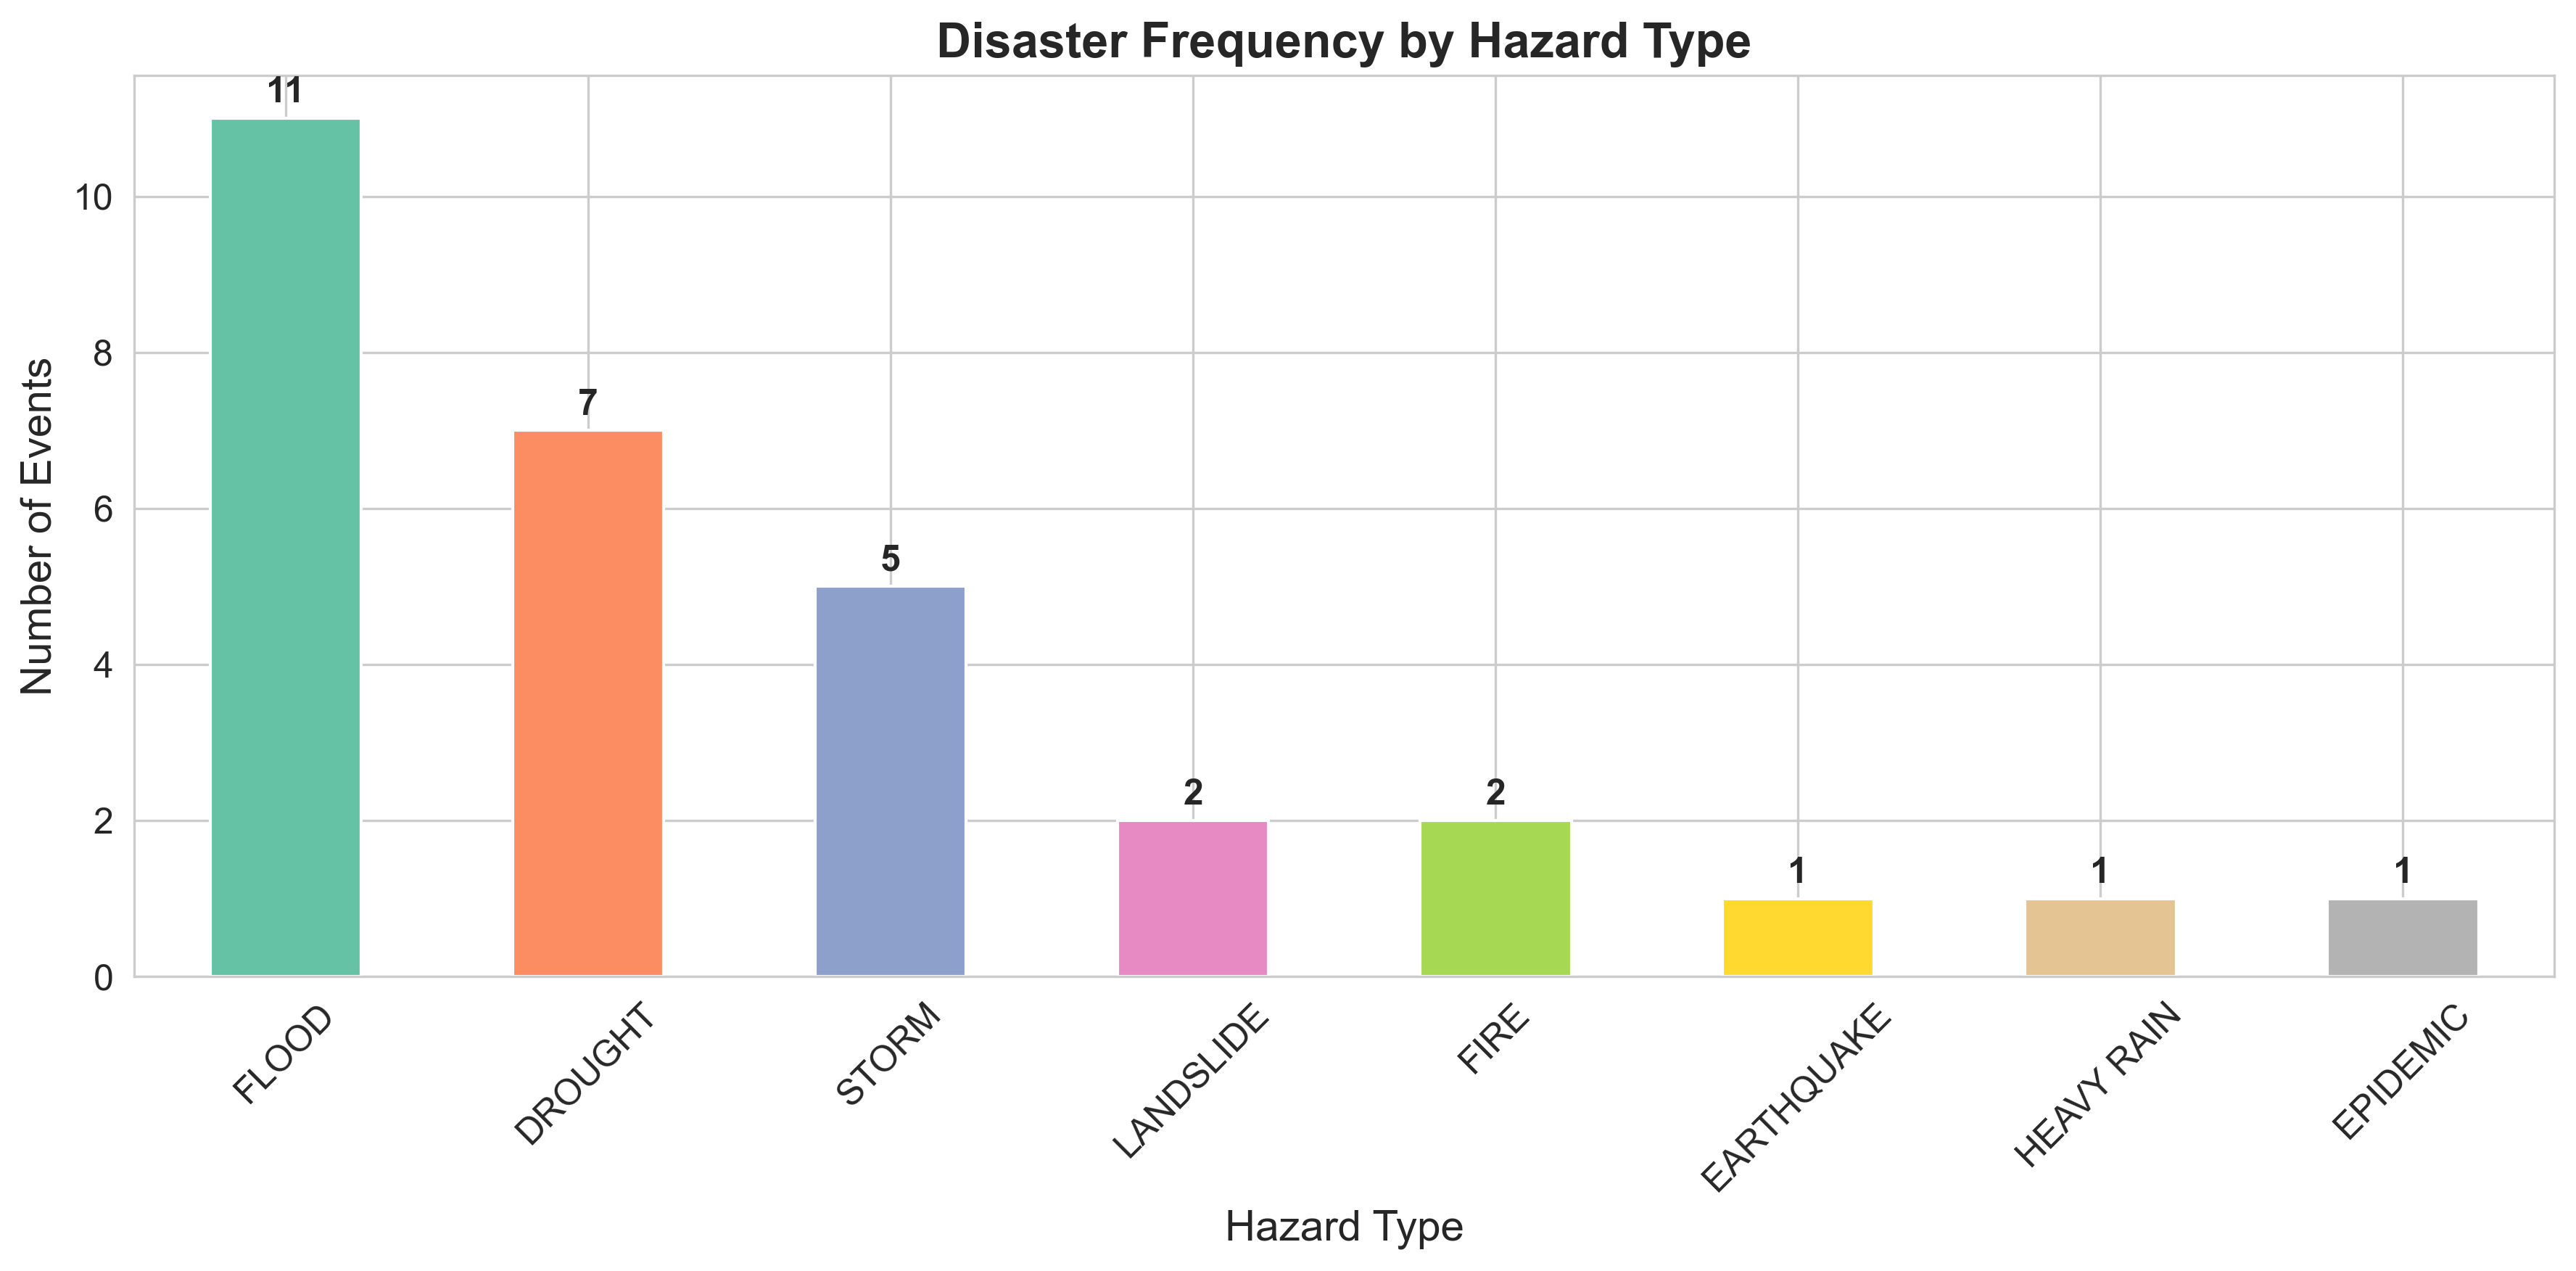

In [6]:
if df_raw is not None and 'hazardtype' in df_raw.columns:
    print("Hazard Type Distribution:")
    hazard_dist = df_raw['hazardtype'].value_counts()
    print(f"\nTotal unique hazard types: {df_raw['hazardtype'].nunique()}")
    print("\nTop 10 hazard types:")
    display(hazard_dist.head(10))
    
    fig = plot_hazard_frequency(df_raw, top_n=15, 
                                 save_path=FIGURES_DIR / '01_hazard_frequency.png')
    plt.show()

## 6. Geographic Coverage

In [7]:
if df_raw is not None:
    print("Geographic Coverage:")
    
    if 'level1' in df_raw.columns:
        print(f"\nCountries/Level 1: {df_raw['level1'].nunique()}")
        print("Top 10 by event count:")
        display(df_raw['level1'].value_counts().head(10))
    
    if 'level2' in df_raw.columns:
        print(f"\nProvinces/Level 2: {df_raw['level2'].nunique()}")
    
    if 'level3' in df_raw.columns:
        print(f"Districts/Level 3: {df_raw['level3'].nunique()}")
    
    if 'latitude' in df_raw.columns and 'longitude' in df_raw.columns:
        coord_available = df_raw[['latitude', 'longitude']].notna().all(axis=1).sum()
        coord_pct = (coord_available / len(df_raw)) * 100
        print(f"\nRecords with coordinates: {coord_available} ({coord_pct:.1f}%)")

Geographic Coverage:

Countries/Level 1: 7
Top 10 by event count:


level1
Kenya         10
Ethiopia       5
Tanzania       5
Uganda         4
Somalia        3
Mozambique     2
Madagascar     1
Name: count, dtype: int64


Provinces/Level 2: 25
Districts/Level 3: 28

Records with coordinates: 30 (100.0%)


## 7. Impact Statistics

In [8]:
if df_raw is not None:
    impact_cols = ['deaths', 'injured', 'missing', 'affected', 'displaced',
                   'housesdestroyed', 'housesdamaged', 'educationcenters', 
                   'healthcenters', 'usdvalue']
    
    available_impact_cols = [col for col in impact_cols if col in df_raw.columns]
    
    if available_impact_cols:
        print("Impact Statistics Summary:")
        impact_stats = df_raw[available_impact_cols].describe()
        display(impact_stats)
        
        print("\nTotal Impacts:")
        for col in available_impact_cols:
            total = df_raw[col].sum()
            records_with_data = df_raw[col].notna().sum()
            print(f"  {col}: {total:,.0f} (data available for {records_with_data} events)")

Impact Statistics Summary:


,deaths,injured,missing,affected,displaced,housesdestroyed,housesdamaged,educationcenters,healthcenters,usdvalue
count,30.000000,30.000000,30.000000,3.000000e+01,30.000000,30.00000,30.000000,30.000000,30.000000,3.000000e+01
mean,336.033333,1173.633333,60.200000,3.292867e+05,58943.333333,5019.00000,17368.333333,30.500000,8.233333,8.379600e+06
std,732.277010,2639.026656,147.180255,3.616927e+05,83392.725571,8504.99178,25367.813177,45.374875,12.909989,1.953112e+07
min,8.000000,0.000000,0.000000,5.600000e+03,0.000000,0.00000,0.000000,0.000000,0.000000,2.760000e+05
25%,45.000000,156.000000,3.500000,6.700000e+04,6425.000000,725.00000,2300.000000,8.000000,2.000000,1.440000e+06
50%,117.500000,345.000000,8.000000,1.560000e+05,20500.000000,2300.00000,7250.000000,12.000000,3.500000,3.420000e+06
75%,234.000000,837.000000,31.250000,4.545000e+05,80500.000000,5600.00000,21750.000000,42.250000,11.250000,6.540000e+06
max,3450.000000,12000.000000,670.000000,1.200000e+06,345000.000000,45000.00000,123000.000000,234.000000,67.000000,1.068000e+08



Total Impacts:
  deaths: 10,081 (data available for 30 events)
  injured: 35,209 (data available for 30 events)
  missing: 1,806 (data available for 30 events)
  affected: 9,878,600 (data available for 30 events)
  displaced: 1,768,300 (data available for 30 events)
  housesdestroyed: 150,570 (data available for 30 events)
  housesdamaged: 521,050 (data available for 30 events)
  educationcenters: 915 (data available for 30 events)
  healthcenters: 247 (data available for 30 events)
  usdvalue: 251,388,000 (data available for 30 events)


## 8. Temporal Trends Visualization

2026-05-23 07:04:33,893 - INFO - Figure saved to D:\Projects\sendai-multi-hazard-risk-modeling\outputs\figures\01_temporal_trends.png


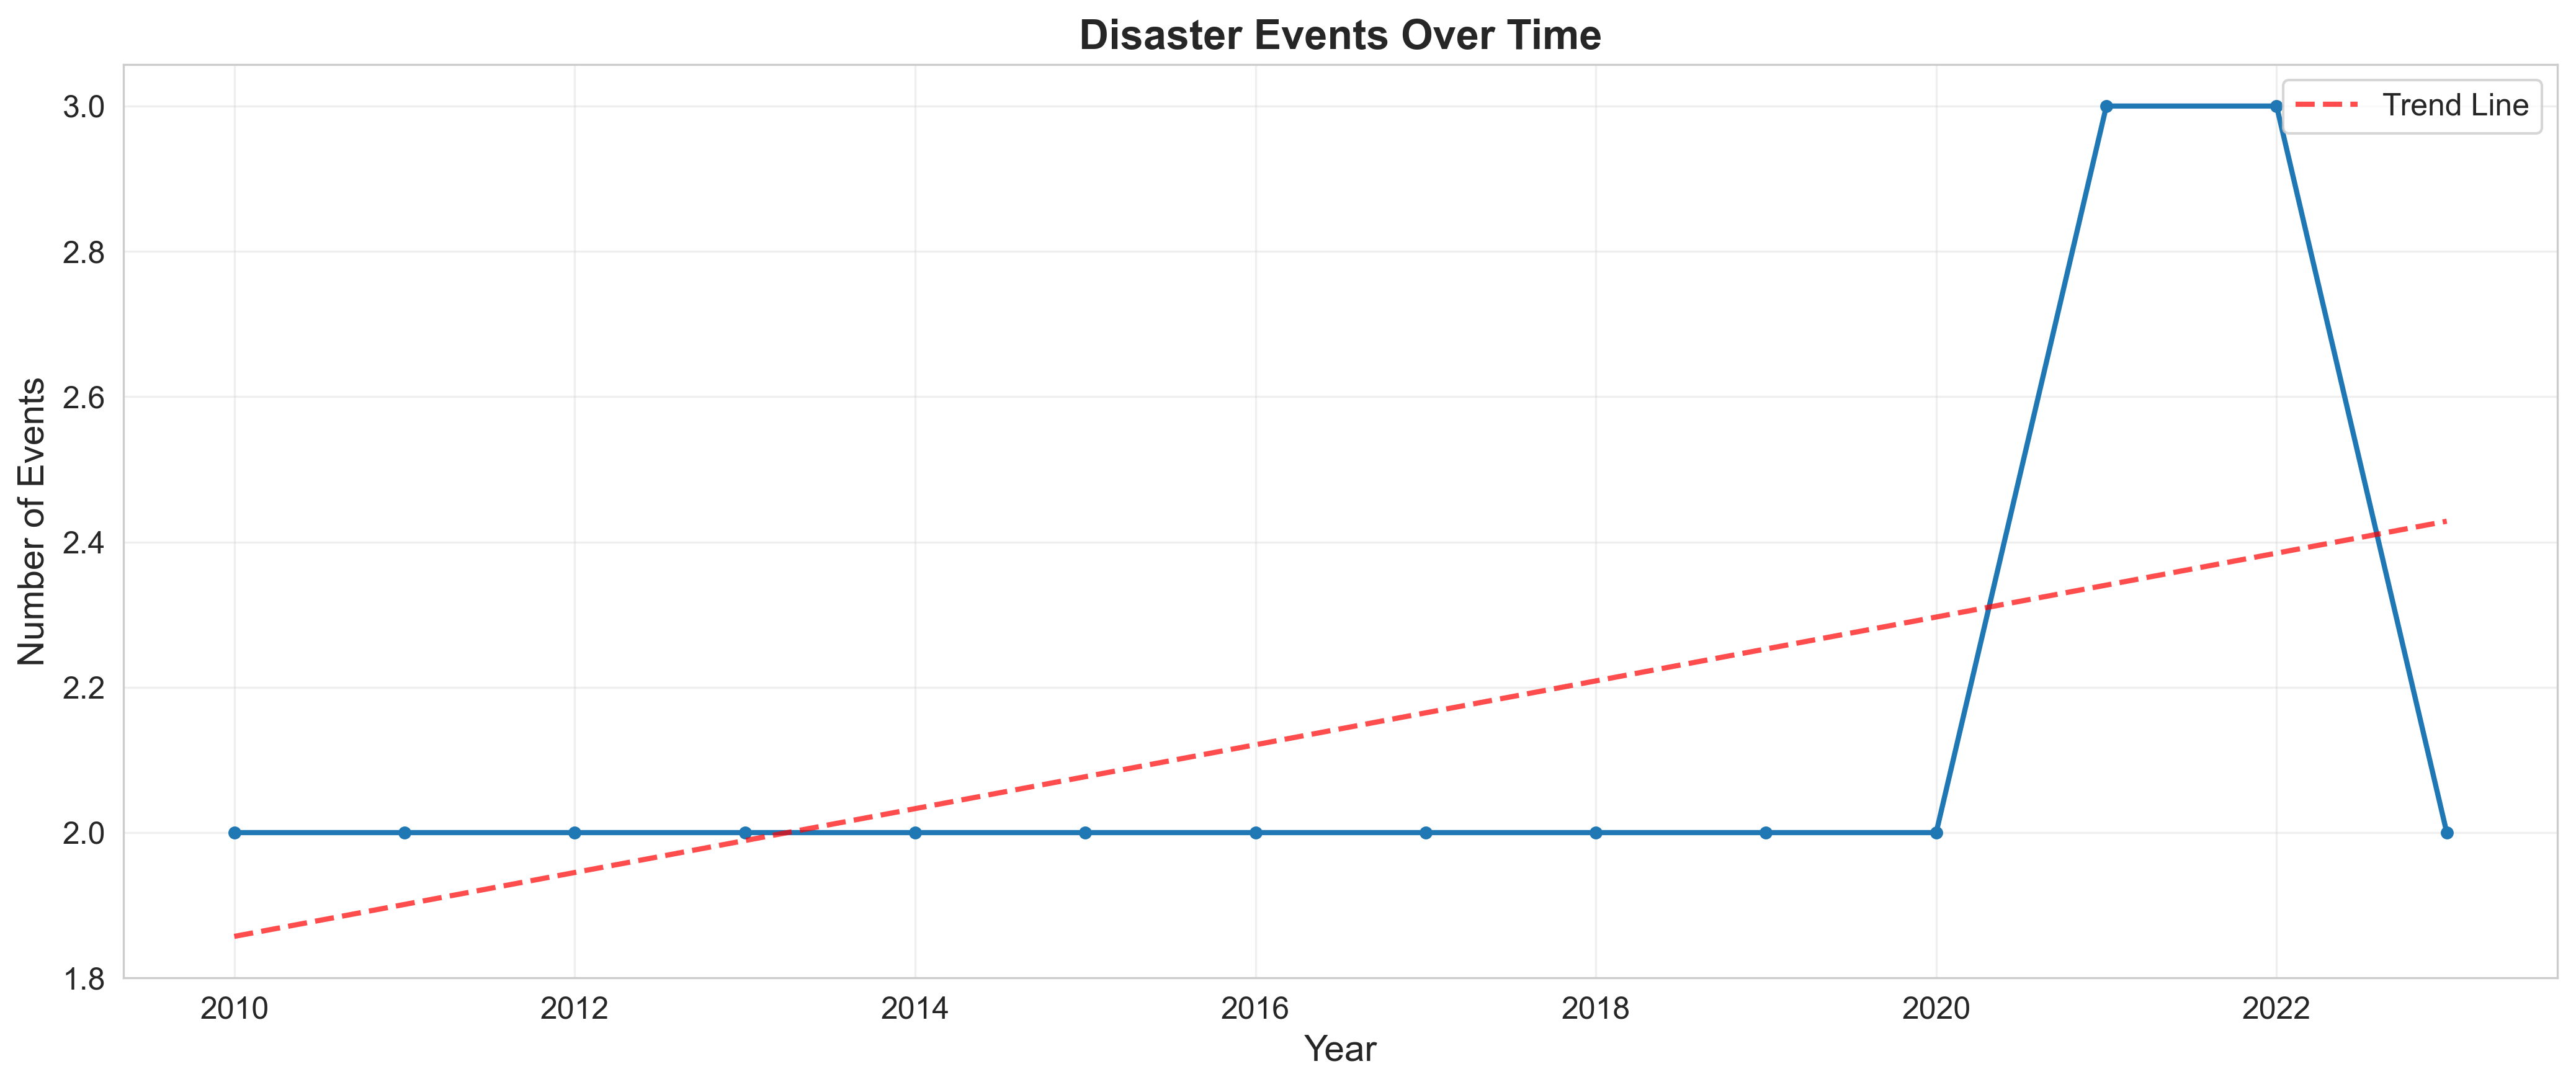

2026-05-23 07:04:35,284 - INFO - Figure saved to D:\Projects\sendai-multi-hazard-risk-modeling\outputs\figures\01_deaths_trends.png


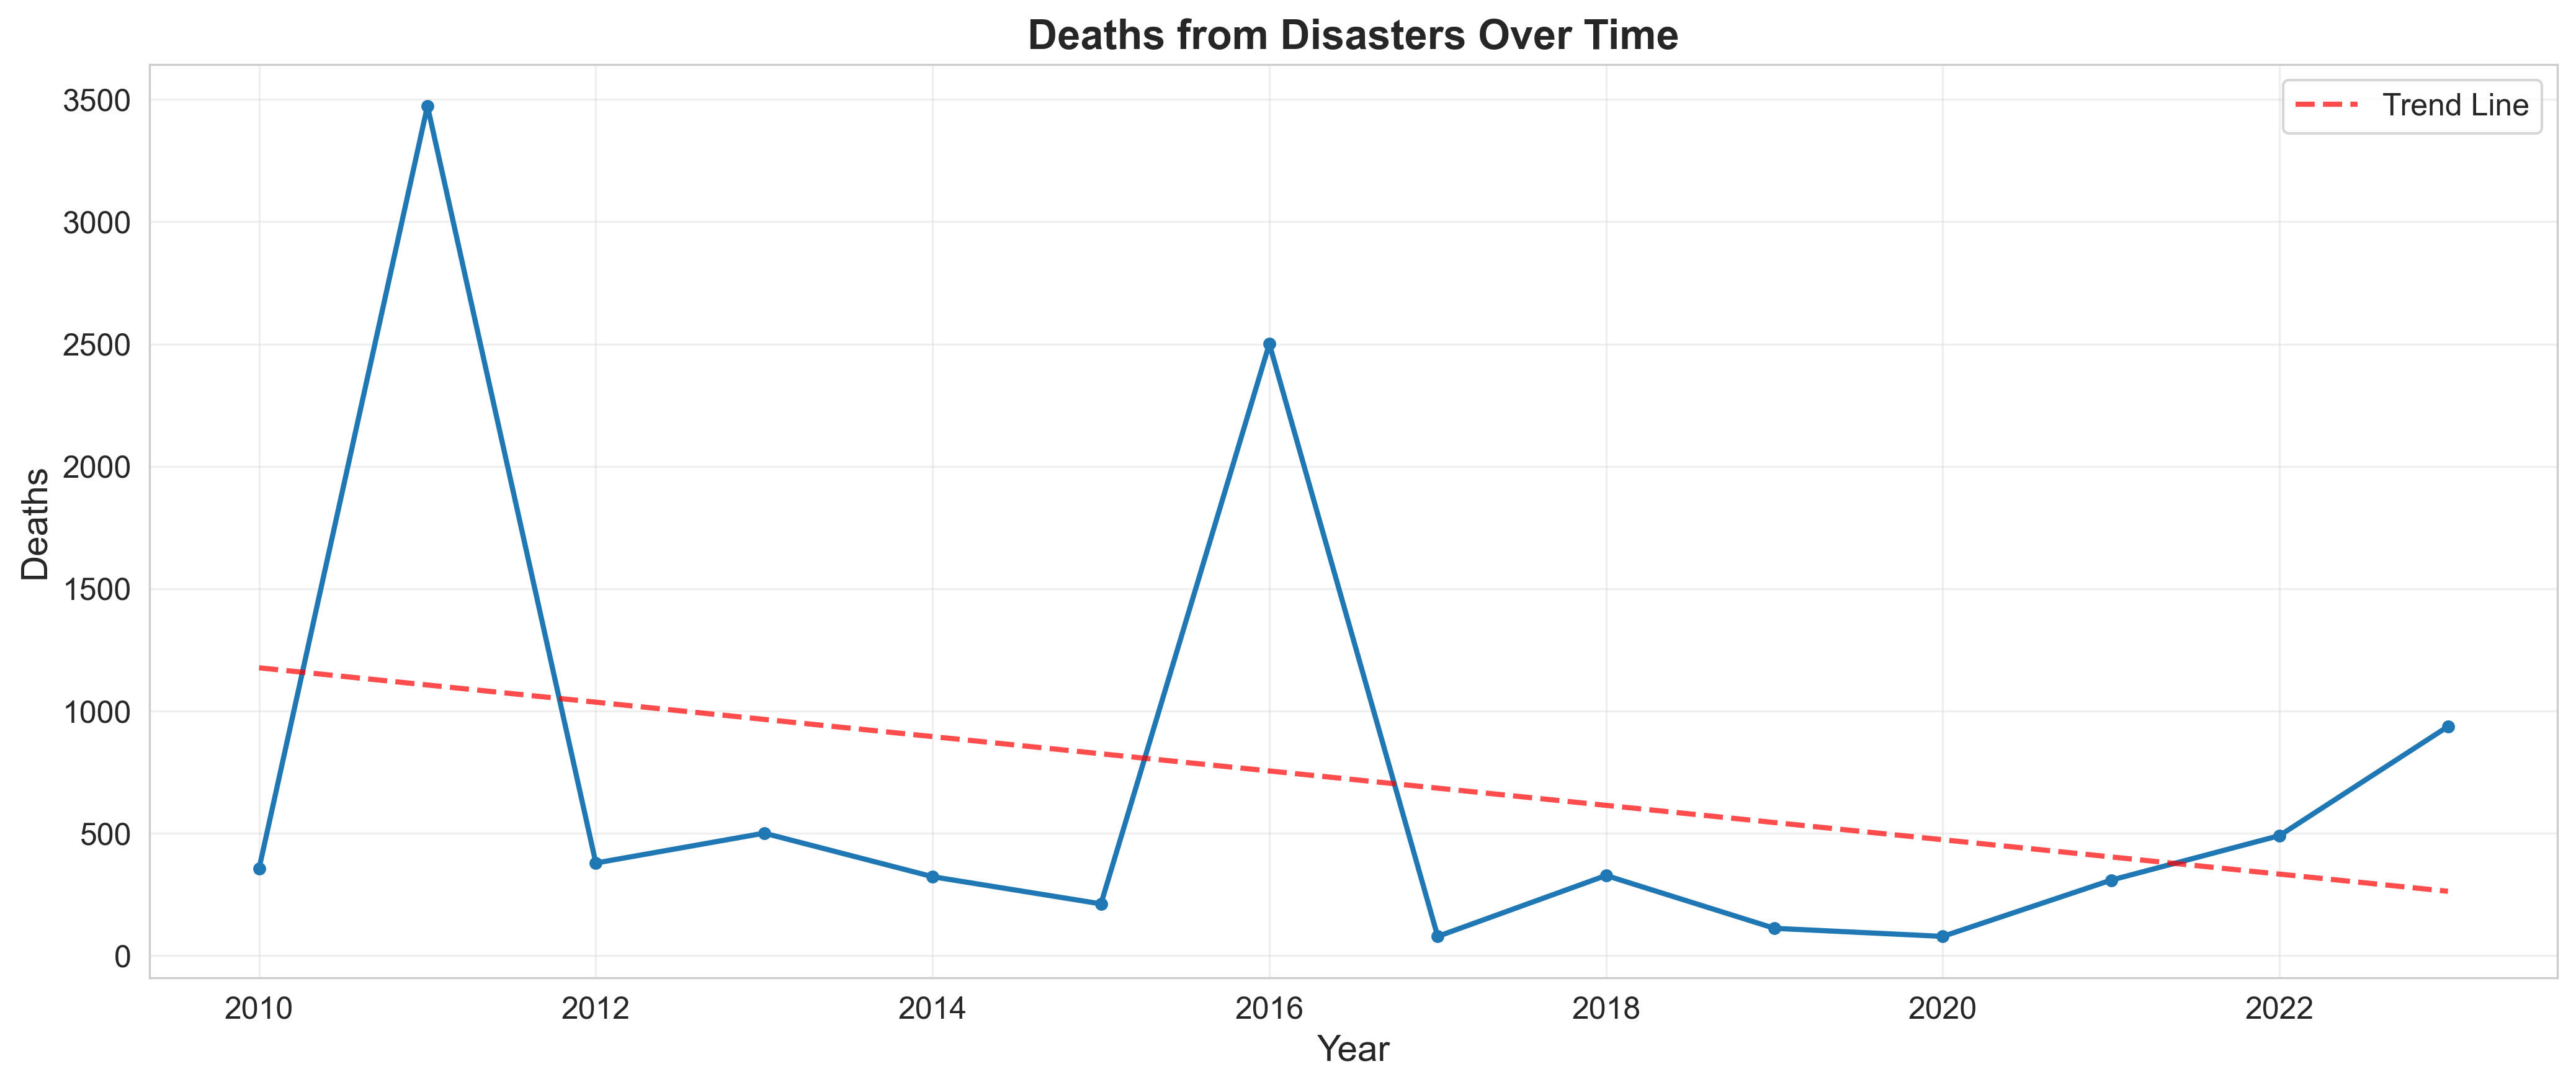

In [9]:
if df_raw is not None and 'year' in df_raw.columns:
    fig = plot_temporal_trends(df_raw, date_col='year',
                               title='Disaster Events Over Time',
                               save_path=FIGURES_DIR / '01_temporal_trends.png')
    plt.show()
    
    if 'deaths' in df_raw.columns:
        fig = plot_temporal_trends(df_raw, date_col='year', value_col='deaths',
                                   title='Deaths from Disasters Over Time',
                                   save_path=FIGURES_DIR / '01_deaths_trends.png')
        plt.show()

## 9. Data Cleaning and Processing

In [10]:
if df_raw is not None:
    print("Cleaning and processing data...")
    
    df_clean = clean_disaster_data(df_raw)
    print(f"After cleaning: {len(df_clean)} records retained ({len(df_clean)/len(df_raw)*100:.1f}%)")
    
    df_processed = add_derived_columns(df_clean)
    print(f"\nAdded derived columns: {[col for col in df_processed.columns if col not in df_clean.columns]}")
    
    output_file = PROCESSED_DATA_DIR / 'disaster_events_processed.csv'
    df_processed.to_csv(output_file, index=False)
    print(f"\nProcessed data saved to: {output_file}")

2026-05-23 07:04:35,881 - INFO - Starting data cleaning process
2026-05-23 07:04:35,925 - INFO - Data cleaning complete. 30 records retained
2026-05-23 07:04:35,927 - INFO - Adding derived columns
2026-05-23 07:04:35,953 - INFO - Added derived columns: ['date', 'season', 'total_affected', 'total_deaths', 'total_houses_affected', 'has_economic_data', 'has_coordinates']


Cleaning and processing data...
After cleaning: 30 records retained (100.0%)

Added derived columns: ['date', 'season', 'total_affected', 'total_deaths', 'total_houses_affected', 'has_economic_data', 'has_coordinates']

Processed data saved to: D:\Projects\sendai-multi-hazard-risk-modeling\data\processed\disaster_events_processed.csv


## 10. Summary and Recommendations

In [11]:
if df_raw is not None:
    print("="*80)
    print("DATA EXPLORATION SUMMARY")
    print("="*80)
    
    print(f"\n📊 Dataset Overview:")
    print(f"   - Total records: {len(df_raw):,}")
    print(f"   - Time period: {df_raw['year'].min()} - {df_raw['year'].max()}")
    print(f"   - Unique hazard types: {df_raw['hazardtype'].nunique()}")
    
    print(f"\n✓ Data Quality:")
    complete_rate = (1 - quality_summary['Null Percentage'].mean()/100) * 100
    print(f"   - Overall completeness: {complete_rate:.1f}%")
    
    print(f"\n📈 Next Steps:")
    print("   1. Proceed to frequency analysis (notebook 02)")
    print("   2. Fetch external population and GDP data for normalization")
    print("   3. Calculate Sendai Framework indicators")
    print("   4. Perform spatial and risk analysis")
    
    if quality_summary['Null Percentage'].max() > 70:
        print(f"\n⚠️  Recommendations:")
        print("   - Some columns have very high missing data rates")
        print("   - Consider data collection improvements for future events")
        print("   - Use available data cautiously for analysis")

DATA EXPLORATION SUMMARY

📊 Dataset Overview:
   - Total records: 30
   - Time period: 2010 - 2023
   - Unique hazard types: 8

✓ Data Quality:
   - Overall completeness: 100.0%

📈 Next Steps:
   1. Proceed to frequency analysis (notebook 02)
   2. Fetch external population and GDP data for normalization
   3. Calculate Sendai Framework indicators
   4. Perform spatial and risk analysis
